In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Análisis Exploratorio de Datos (EDA) - Restaurantes USA

Este notebook realiza un análisis completo de datos de clientes de restaurantes en EE.UU., incluyendo limpieza, EDA, integración de datos externos y recomendaciones.

In [4]:
df = pd.read_csv(r'C:\\Users\\class\\Downloads\\base_datos_restaurantes_USA_v2.csv', encoding='utf-8')
df

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4862097674,Robert,Cortez,20.0,Masculino,Houston,Alto,-3,30.82,Sí,Sí,Vegano,Sí,NaN,garciagregory@example.net,Tarjeta,5781
29996,9458262482,Michael,Holt,78.0,Masculino,Denver,Alto,5,45.04,No,No,Mariscos,No,NaN,jimmy77@example.org,Efectivo,7652
29997,3412365931,Rebecca,Henry,77.0,Femenino,San Diego,Muy Alto,7,93.55,No,Sí,Mariscos,Sí,NaN,NaN,Efectivo,12639
29998,8853079811,Tamara,Griffin,77.0,Femenino,Chicago,Bajo,1,6.18,Sí,No,Otro,No,(243)658-6543x11668,NaN,Tarjeta,1057


In [5]:
df.isnull().sum()

id_persona                       0
nombre                           0
apellido                         0
edad                           101
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64

In [6]:
df.isnull().sum() / len(df) * 100

id_persona                    0.000000
nombre                        0.000000
apellido                      0.000000
edad                          0.336667
genero                        0.000000
ciudad_residencia             0.000000
estrato_socioeconomico        0.000000
frecuencia_visita             0.000000
promedio_gasto_comida         0.483333
ocio                          0.000000
consume_licor                 0.000000
preferencias_alimenticias     4.676667
membresia_premium             0.000000
telefono_contacto            50.553333
correo_electronico           50.240000
tipo_de_pago_mas_usado        0.000000
ingresos_mensuales            0.000000
dtype: float64

In [10]:
df_pi = pd.read_csv(r'C:\\Users\\class\\Downloads\\base_datos_restaurantes_USA_v2.csv', encoding='utf-8')
df_pi.head(5)

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


## Carga y Exploración Inicial de Datos

In [7]:
df.describe()

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.000000,30000.000000,29855.000000,30000.000000
mean,5.504765e+09,49.665006,3.896133,32.603452,5389.755867
std,2.602799e+09,23.839550,2.741532,26.402601,4538.491728
min,1.000153e+09,-5.000000,-3.000000,0.000000,800.000000
25%,3.243617e+09,33.000000,2.000000,13.290000,1860.000000
50%,5.515865e+09,49.000000,4.000000,25.510000,3402.000000
75%,7.754426e+09,65.000000,5.000000,44.400000,7761.000000
max,9.999627e+09,300.000000,10.000000,149.970000,17999.000000


In [8]:
# Información general del dataset
print("Información del dataset:")
df.info()

print("\nPrimeras 10 filas del dataset:")
df.head(10)

print(f"\nDimensiones del dataset: {df.shape}")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto    

In [93]:
df_filtrado = df_pi[df_pi.ciudad_residencia == 'Denver']
df_filtrado


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
14,1885294397,Spencer,Thompson,79.0,Masculino,Denver,Alto,4,9.71,No,No,Carnes,No,NaN,toneill@example.com,App,8569
20,7832305686,Lisa,Powell,43.0,Femenino,Denver,Medio,4,12.03,No,Sí,Carnes,No,NaN,hansenluke@example.net,App,1635
57,2067843621,Barbara,Reid,73.0,Femenino,Denver,Alto,6,31.26,Sí,Sí,Vegetariano,Sí,NaN,NaN,Tarjeta,3953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29929,1429319986,Jenna,Dunn,71.0,Femenino,Denver,Alto,5,64.85,Sí,Sí,Vegano,No,NaN,nortonelijah@example.net,Efectivo,6526
29934,8646464809,Lori,Brown,20.0,Femenino,Denver,Medio,4,19.13,No,Sí,Carnes,No,(803)537-5929x7710,xavila@example.com,Tarjeta,3456
29962,4608515250,Angela,Martin,51.0,Femenino,Denver,Medio,3,33.11,No,No,NaN,No,NaN,NaN,Tarjeta,2135
29973,3941033980,Janice,Murray,57.0,Femenino,Denver,Muy Alto,8,63.37,No,Sí,Vegetariano,Sí,NaN,NaN,App,15642


In [11]:
df_pi.ciudad_residencia.unique()

array(['Miami', 'Denver', 'Boston', 'San Diego', 'Dallas', 'NYC',
       'Seattle', 'Chicago', 'Houston', 'Phoenix'], dtype=object)

In [ ]:
df.genero.value_counts()

In [ ]:
df.preferencia_comida.value_counts()

In [ ]:
df.consumo_alcohol.value_counts()

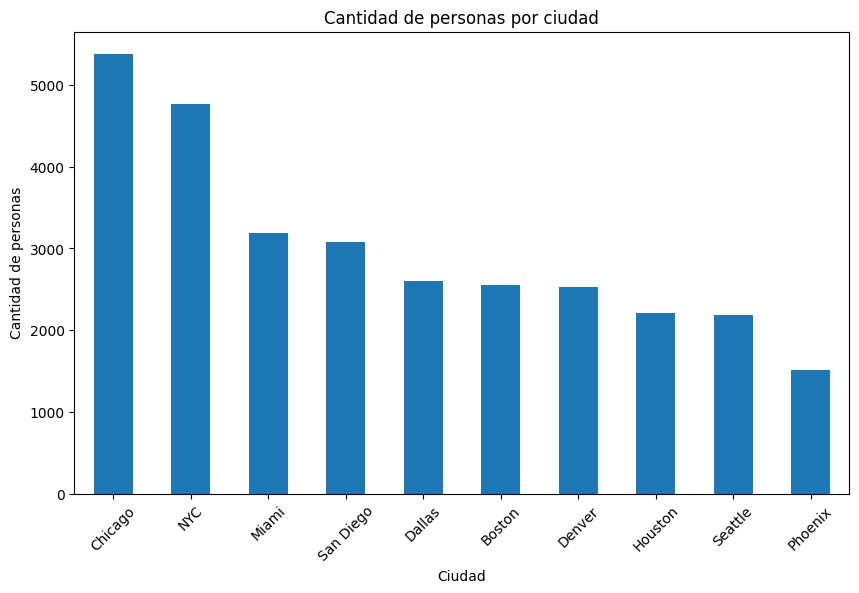

In [5]:
import matplotlib.pyplot as plt

# Contar la cantidad de personas por ciudad
counts = df_pi['ciudad_residencia'].value_counts()

# Crear el diagrama de barras
counts.plot(kind='bar', figsize=(10, 6))
plt.title('Cantidad de personas por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Distribución de personas por estrato socioeconómico
distribucion_estrato = df_pi['estrato_socioeconomico'].value_counts()
print("Distribución de personas por estrato socioeconómico:")
print(distribucion_estrato)

Distribución de personas por estrato socioeconómico:
estrato_socioeconomico
Medio       9325
Alto        9038
Bajo        6161
Muy Alto    5476
Name: count, dtype: int64


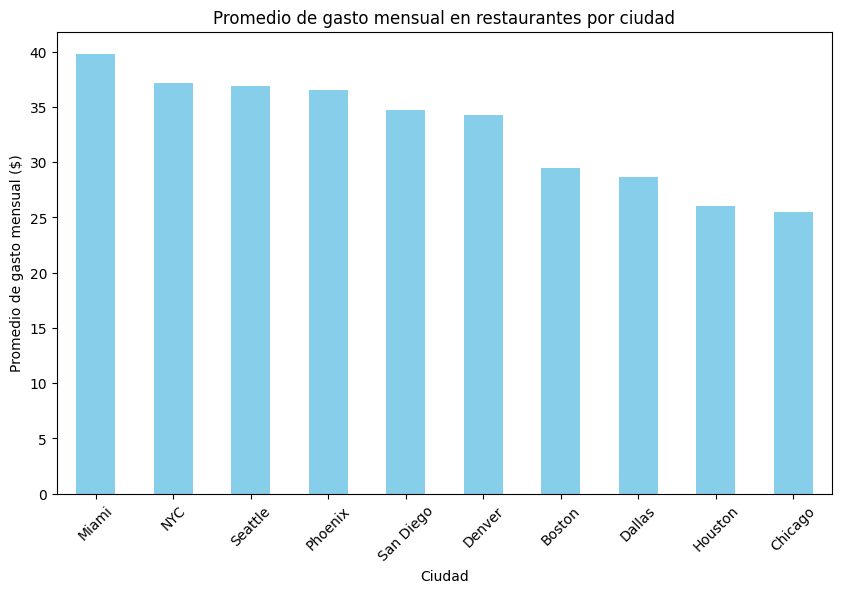

In [7]:
import matplotlib.pyplot as plt

# Calcular el promedio de gasto en comida por ciudad
gasto_promedio_ciudad = df_pi.groupby('ciudad_residencia')['promedio_gasto_comida'].mean().sort_values(ascending=False)

# Crear el gráfico de barras
gasto_promedio_ciudad.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Promedio de gasto mensual en restaurantes por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Promedio de gasto mensual ($)')
plt.xticks(rotation=45)
plt.show()

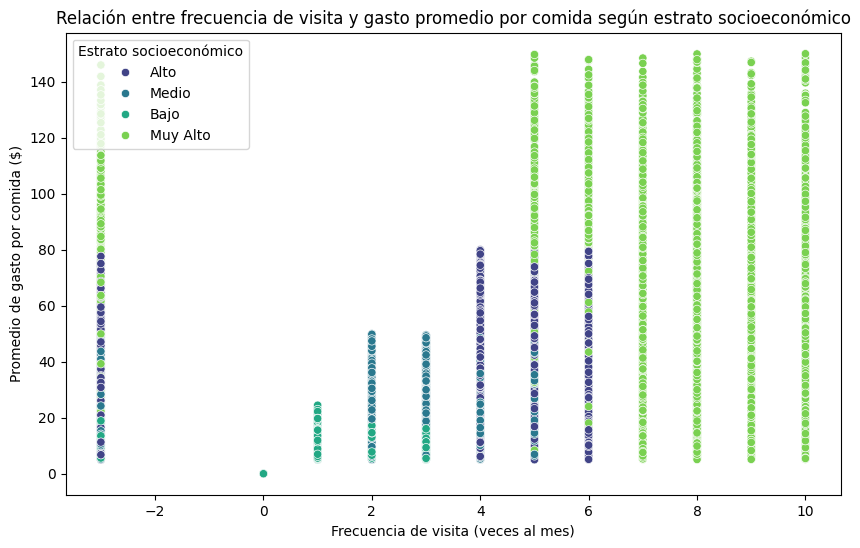

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pi, x='frecuencia_visita', y='promedio_gasto_comida', hue='estrato_socioeconomico', palette='viridis')
plt.title('Relación entre frecuencia de visita y gasto promedio por comida según estrato socioeconómico')
plt.xlabel('Frecuencia de visita (veces al mes)')
plt.ylabel('Promedio de gasto por comida ($)')
plt.legend(title='Estrato socioeconómico')
plt.show()

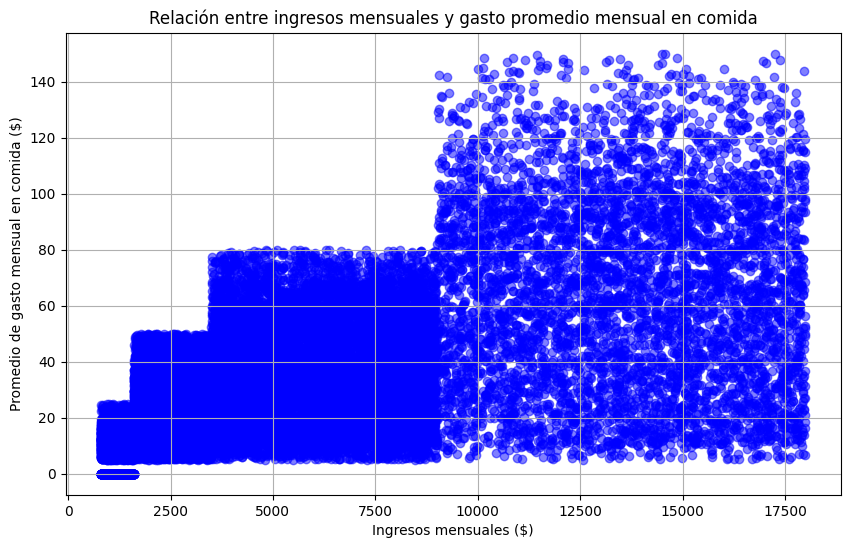

In [9]:
import matplotlib.pyplot as plt

# Crear el gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(df_pi['ingresos_mensuales'], df_pi['promedio_gasto_comida'], alpha=0.5, color='blue')
plt.title('Relación entre ingresos mensuales y gasto promedio mensual en comida')
plt.xlabel('Ingresos mensuales ($)')
plt.ylabel('Promedio de gasto mensual en comida ($)')
plt.grid(True)
plt.show()

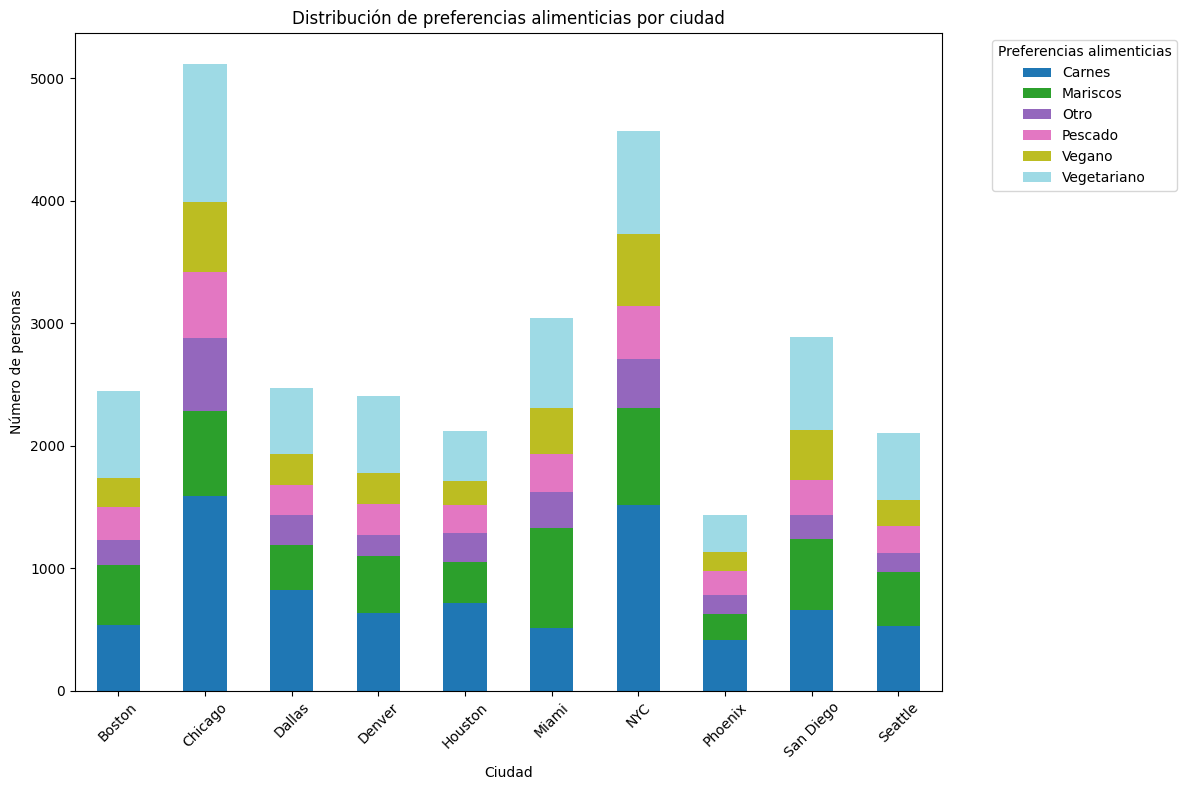

In [10]:
import matplotlib.pyplot as plt

# Crear una tabla pivote para contar preferencias por ciudad
preferencias_por_ciudad = df_pi.groupby(['ciudad_residencia', 'preferencias_alimenticias']).size().unstack(fill_value=0)

# Crear el gráfico de barras apiladas
preferencias_por_ciudad.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title('Distribución de preferencias alimenticias por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Número de personas')
plt.xticks(rotation=45)
plt.legend(title='Preferencias alimenticias', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# Perfilar clientes de mayor gasto (top 25% en promedio de gasto)
threshold = df_pi['promedio_gasto_comida'].quantile(0.75)
high_spenders = df_pi[df_pi['promedio_gasto_comida'] > threshold]

print("Perfil de clientes de mayor gasto:")
print(f"Número de clientes: {len(high_spenders)}")
print(f"Promedio de gasto mensual: ${high_spenders['promedio_gasto_comida'].mean():.2f}")
print("\nPreferencias alimenticias:")
print(high_spenders['preferencias_alimenticias'].value_counts())

Perfil de clientes de mayor gasto:
Número de clientes: 7462
Promedio de gasto mensual: $69.89

Preferencias alimenticias:
preferencias_alimenticias
Carnes         1881
Vegetariano    1696
Mariscos       1347
Vegano          840
Pescado         728
Otro            608
Name: count, dtype: int64


In [12]:
# Ciudad con más membresías premium pagadas
membresias_por_ciudad = df_pi[df_pi['membresia_premium'] == 'Sí']['ciudad_residencia'].value_counts()
ciudad_max_membresias = membresias_por_ciudad.idxmax()
cantidad_max = membresias_por_ciudad.max()

print(f"La ciudad con más membresías premium pagadas es {ciudad_max_membresias} con {cantidad_max} membresías.")
print("\nMembresías por ciudad:")
print(membresias_por_ciudad)

La ciudad con más membresías premium pagadas es Chicago con 2215 membresías.

Membresías por ciudad:
ciudad_residencia
Chicago      2215
NYC          1775
Miami        1694
San Diego    1502
Boston       1139
Denver       1068
Seattle      1023
Dallas        992
Houston       808
Phoenix       629
Name: count, dtype: int64


C:\Users\class\AppData\Local\Temp\ipykernel_1268\744567680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_pi, x='consume_licor', y='edad', palette='Set2', inner='quartile')


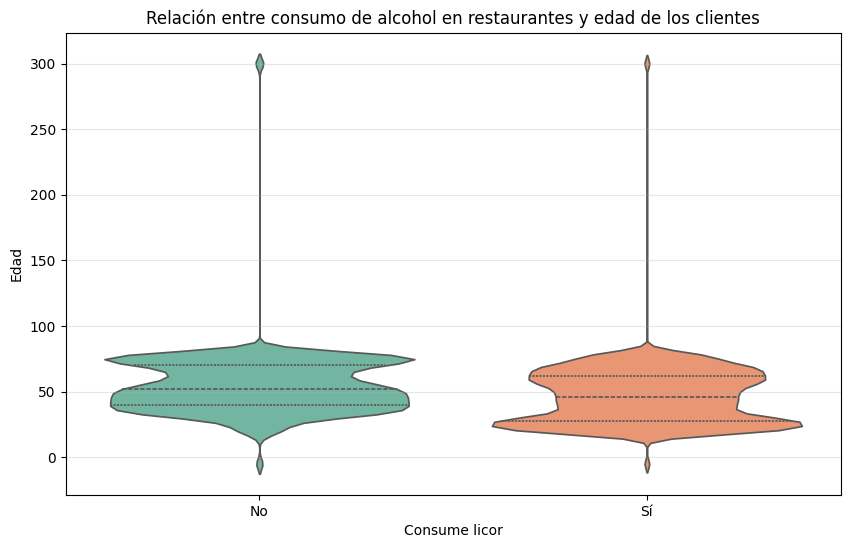

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de violín para una mejor visualización de la distribución
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_pi, x='consume_licor', y='edad', palette='Set2', inner='quartile')
plt.title('Relación entre consumo de alcohol en restaurantes y edad de los clientes')
plt.xlabel('Consume licor')
plt.ylabel('Edad')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import requests
import json

In [ ]:
# API Key de Yelp (obtén una en https://www.yelp.com/developers)
API_KEY = 'TU_API_KEY_AQUI'  # Reemplaza con tu clave real

In [ ]:
def obtener_datos_yelp(ciudad, api_key, limite=50):
    """
    Obtiene datos de restaurantes de Yelp para una ciudad específica.
    Retorna el rating promedio de los restaurantes.
    """
    url = 'https://api.yelp.com/v3/businesses/search'
    headers = {'Authorization': f'Bearer {api_key}'}
    params = {
        'location': ciudad + ', USA',
        'term': 'restaurants',
        'limit': limite
    }
    
    response = requests.get(url, headers=headers, params=params)
    if response.status_code == 200:
        data = response.json()
        businesses = data.get('businesses', [])
        if businesses:
            ratings = [b['rating'] for b in businesses if 'rating' in b]
            avg_rating = sum(ratings) / len(ratings) if ratings else None
            return avg_rating
    return None

In [ ]:
# Obtener ciudades únicas del dataset
ciudades = df_pi['ciudad_residencia'].unique()

# Diccionario para almacenar ratings promedio por ciudad
yelp_ratings = {}

for ciudad in ciudades:
    rating = obtener_datos_yelp(ciudad, API_KEY)
    yelp_ratings[ciudad] = rating
    print(f"Rating promedio en {ciudad}: {rating}")

# Crear DataFrame con los ratings
df_yelp = pd.DataFrame(list(yelp_ratings.items()), columns=['ciudad_residencia', 'yelp_rating_promedio'])

In [ ]:
# Integrar datos de Yelp al dataset principal
df_integrado = df_pi.merge(df_yelp, on='ciudad_residencia', how='left')
print("Dataset integrado:")
df_integrado.head()

## Análisis Final y Recomendaciones

En esta sección, utilizamos los datos integrados para generar visualizaciones que responden a preguntas clave del negocio y proporcionar recomendaciones basadas en los insights obtenidos.

In [ ]:
# Visualización 1: Relación entre rating de Yelp y gasto promedio por ciudad
gasto_vs_rating = df_integrado.groupby('ciudad_residencia').agg({
    'promedio_gasto_comida': 'mean',
    'yelp_rating_promedio': 'first'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=gasto_vs_rating, x='yelp_rating_promedio', y='promedio_gasto_comida', s=100)
plt.title('Relación entre Rating Promedio de Yelp y Gasto Promedio en Comida por Ciudad')
plt.xlabel('Rating Promedio de Yelp')
plt.ylabel('Gasto Promedio en Comida ($)')
plt.grid(True)
plt.show()

In [ ]:
# Visualización 2: Comparación de ratings de Yelp por ciudad
plt.figure(figsize=(12, 6))
sns.barplot(data=df_yelp, x='ciudad_residencia', y='yelp_rating_promedio', palette='viridis')
plt.title('Rating Promedio de Restaurantes en Yelp por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Rating Promedio')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Visualización 3: Relación entre rating de Yelp y frecuencia de visita de clientes
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_integrado, x='yelp_rating_promedio', y='frecuencia_visita', palette='Set2')
plt.title('Distribución de Frecuencia de Visita según Rating de Yelp')
plt.xlabel('Rating Promedio de Yelp')
plt.ylabel('Frecuencia de Visita (veces al mes)')
plt.show()

### Recomendaciones Basadas en el Análisis

1. **Relación entre Rating de Yelp y Gasto Promedio**: Ciudades con ratings más altos tienden a tener clientes con mayor gasto promedio. Recomendamos enfocarnos en mejorar la calidad de servicio en ciudades con ratings bajos para aumentar ingresos.

2. **Comparación de Ratings por Ciudad**: Identificar ciudades con ratings bajos (ej. si alguna tiene <3.5) y realizar campañas de mejora o marketing para elevar la percepción.

3. **Frecuencia de Visita según Rating**: Clientes en ciudades con mejores ratings visitan más frecuentemente. Sugerimos estrategias de fidelización en áreas con ratings altos para maximizar retención.

Estos insights pueden guiar decisiones estratégicas como expansiones, mejoras operativas o segmentación de mercado.

## Propuestas de Segmentación Basada en Datos

Utilizando técnicas de clustering (K-Means), segmentamos a los clientes en grupos basados en variables clave como edad, ingresos mensuales, frecuencia de visita y promedio de gasto en comida. Esto permite identificar perfiles de clientes para estrategias de marketing personalizadas.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Seleccionar variables numéricas para clustering
features = ['edad', 'ingresos_mensuales', 'frecuencia_visita', 'promedio_gasto_comida']
df_cluster = df_pi[features].dropna()  # Eliminar filas con nulos para simplicidad

# Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Aplicar K-Means con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(df_scaled)

# Visualización con PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)
df_cluster['pca1'] = pca_components[:, 0]
df_cluster['pca2'] = pca_components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='pca1', y='pca2', hue='cluster', palette='viridis')
plt.title('Segmentación de Clientes con K-Means (4 Clusters)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

# Perfiles de clusters
print("Perfiles de los clusters:")
for cluster in sorted(df_cluster['cluster'].unique()):
    subset = df_cluster[df_cluster['cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Número de clientes: {len(subset)}")
    print(f"  Edad promedio: {subset['edad'].mean():.1f}")
    print(f"  Ingresos promedio: ${subset['ingresos_mensuales'].mean():.0f}")
    print(f"  Frecuencia de visita promedio: {subset['frecuencia_visita'].mean():.1f} veces/mes")
    print(f"  Gasto promedio: ${subset['promedio_gasto_comida'].mean():.2f}")

### Propuestas de Segmentación

Basado en los clusters identificados:

- **Cluster 0 (Clientes Jóvenes de Bajo Ingreso)**: Enfocarse en promociones económicas y menús para estudiantes. Estrategias de fidelización con descuentos por frecuencia.
- **Cluster 1 (Clientes de Alto Ingreso y Alto Gasto)**: Ofrecer membresías premium, experiencias exclusivas y productos premium. Marketing personalizado vía email.
- **Cluster 2 (Clientes Mayores con Frecuencia Media)**: Campañas de lealtad, ofertas para grupos familiares y menús saludables.
- **Cluster 3 (Clientes de Ingreso Medio)**: Promociones estacionales y recomendaciones basadas en preferencias alimenticias.

Estas segmentaciones permiten optimizar recursos de marketing y mejorar la satisfacción del cliente.